## **1. Install Dependencies & Import Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/qp_ai_vision-main/src/

/content/drive/MyDrive/qp_ai_vision-main/src


In [3]:
!pip install -q torch torchvision ultralytics kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 7.2 MB/s eta 0:00:00


## **2. Download the dataset**

In [4]:
import kagglehub

dataset_root = kagglehub.dataset_download("nadinpethiyagoda/vehicle-dataset-for-yolo")
print("Downloaded to:", dataset_root)

100%|██████████| 375M/375M [00:09<00:00, 39.8MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/versions/1


In [5]:
import os
os.environ["VEHICLE_DATASET_ROOT"] = dataset_root

## **3. Defining size and Testing**

In [ ]:
from rsw_ai.backend.import_nadinpethiyagoda_vehicle_dataset_for_yolo_to_VisionYoloDataset import (
    import_nadinpethiyagoda_vehicle_dataset_for_yolo_to_VisionYoloDataset,
)
from rsw_ai.training.config import DATASET_ROOT

vision_dataset = import_nadinpethiyagoda_vehicle_dataset_for_yolo_to_VisionYoloDataset(DATASET_ROOT)
print("Classes:", vision_dataset.class_map.names)
for split in vision_dataset.splits:
    print(f"  split={split.name:<6} samples={len(split.samples)}")

Classes: ['car', 'threewheel', 'bus', 'truck', 'motorbike', 'van']
  split=train  samples=2100
  split=valid  samples=900


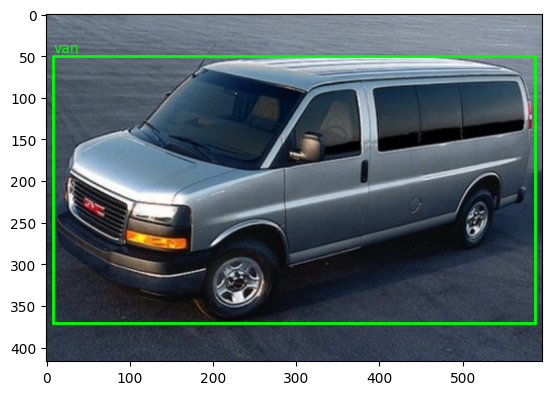

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

train_split = next(s for s in vision_dataset.splits if s.name == "train")
sample = train_split.samples[0]
image = Image.open(sample.input)
w, h = image.size

fig, ax = plt.subplots(1)
ax.imshow(image)
for ann in sample.target:
    x1 = (ann.center_x - ann.width / 2) * w
    y1 = (ann.center_y - ann.height / 2) * h
    box_w = ann.width * w
    box_h = ann.height * h
    ax.add_patch(patches.Rectangle((x1, y1), box_w, box_h, linewidth=2, edgecolor="lime", facecolor="none"))
    ax.text(x1, y1 - 5, vision_dataset.class_map.get_name(ann.class_id), color="lime")
plt.show()

## **4. Training Model**

In [ ]:
!python -m rsw_ai.training.train_faster_rcnn

[INFO] Importing dataset from /root/.cache/kagglehub/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/versions/1/vehicle dataset using the repo's own importer...
[INFO] Loaded dataset 'nadinpethiyagoda_vehicle_dataset_for_yolo' -- 6 classes: ['car', 'threewheel', 'bus', 'truck', 'motorbike', 'van']
[INFO] 2100 training samples
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100% 160M/160M [00:01<00:00, 121MB/s]
[INFO] Training Faster R-CNN for 10 epochs on device=cuda ...
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
[Epoch 1/10] avg_loss=0.4527 time=401.6s
/us

## **5. Evaluate**

In [ ]:
!python -m rsw_ai.training.evaluate_faster_rcnn

[INFO] Evaluating on 900 validation samples
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
{'algorithm': 'Faster R-CNN', 'precision': 0.7602, 'recall': 0.8918, 'mAP50': 0.8207, 'avg_inference_time_ms': 80.66, 'fps': 12.4}
[INFO] Saved metrics -> /content/drive/MyDrive/qp_ai_vision-main/outputs/experiments/faster_rcnn/metrics.json


## **6. Try one image**

In [6]:
%ls

images/  rsw_ai/  rsw_ai.egg-info/


Saving BC53E68CCB869A505E00F25A34A3B830_data_0.jpg to BC53E68CCB869A505E00F25A34A3B830_data_0.jpg
Uploaded to: /content/drive/MyDrive/qp_ai_vision-main/src/images/BC53E68CCB869A505E00F25A34A3B830_data_0.jpg


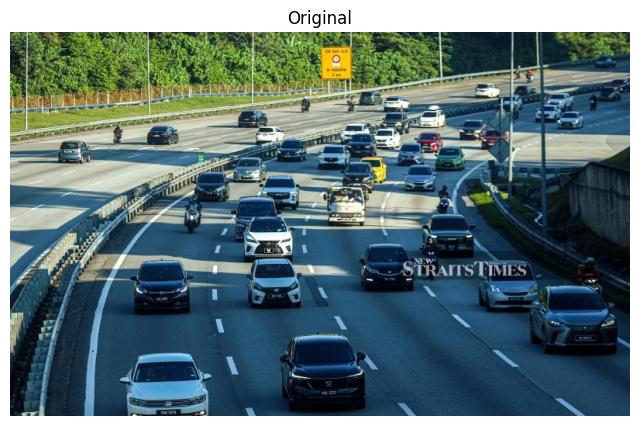

  car          score=0.84  box=(664,326,776,413)
  car          score=0.72  box=(178,120,217,146)
  car          score=0.65  box=(64,140,101,171)
  car          score=0.62  box=(316,122,352,146)
  car          score=0.59  box=(294,99,335,125)
  car          score=0.54  box=(507,171,550,208)
  car          score=0.54  box=(236,182,282,223)
  car          score=0.53  box=(341,388,456,482)
  car          score=0.51  box=(705,103,740,126)
[INFO] 9 vehicle(s) found in 165.1 ms
[INFO] Saved annotated image -> /content/drive/MyDrive/qp_ai_vision-main/src/images/BC53E68CCB869A505E00F25A34A3B830_data_0_predicted.jpg


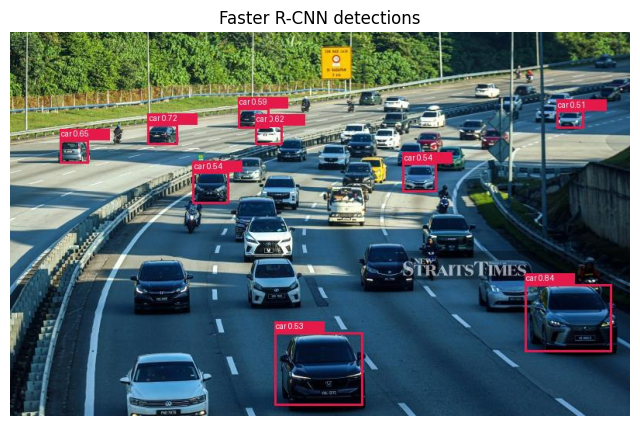

In [8]:
from rsw_ai.training.predict_faster_rcnn import predict
from google.colab import files
from pathlib import Path
from rsw_ai.training.config import PROJECT_ROOT

IMAGES_DIR = PROJECT_ROOT / "src/images"
IMAGES_DIR.mkdir(exist_ok=True)

uploaded = files.upload()
image_path = next(iter(uploaded))
uploaded_path = IMAGES_DIR / image_path
Path(image_path).rename(uploaded_path)
print("Uploaded to:", uploaded_path)

from PIL import Image
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.imshow(Image.open(uploaded_path))
plt.axis("off")
plt.title("Original")
plt.show()

# Faster R-CNN algorithm run
output_path = predict(str(uploaded_path))

plt.figure(figsize=(8, 8))
plt.imshow(Image.open(output_path))
plt.axis("off")
plt.title("Faster R-CNN detections")
plt.show()